In [46]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adamax, Adam, RMSprop

In [47]:
train_dir = r"D:\PHD Project\Balanced_Split\train"
test_dir = r"D:\PHD Project\Balanced_Split\test"

In [48]:
# ✅ Image parameters
img_size = (128, 128)
batch_size = 32

In [49]:
# ✅ Create training and testing datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    r"D:\PHD Project\Balanced_Split\train",
    image_size=(128, 128),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    r"D:\PHD Project\Balanced_Split\test",
    image_size=(128, 128),
    batch_size=32
)

# ✅ Save class names before normalization
class_names = train_ds.class_names
print("Detected classes:", class_names)

Found 1155 files belonging to 3 classes.
Found 498 files belonging to 3 classes.
Detected classes: ['major-damage', 'minor-damage', 'unknown']


In [50]:
# 🚀 Optimize input pipeline
# ===========================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [51]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(512, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # fixed
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, mode='min')

history = model.fit(train_ds, validation_data=test_ds, epochs=30, callbacks=[early_stopping])

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 33s 857ms/step - accuracy: 0.3273 - loss: 4.7514 - val_accuracy: 0.3876 - val_loss: 1.1190
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.3429 - loss: 1.2358 - val_accuracy: 0.3373 - val_loss: 1.1699
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.3584 - loss: 1.2037 - val_accuracy: 0.3474 - val_loss: 1.1427
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 37s 943ms/step - accuracy: 0.3524 - loss: 1.1778 - val_accuracy: 0.3554 - val_loss: 1.1205
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.3385 - loss: 1.1678 - val_accuracy: 0.3815 - val_loss: 1.0933
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.3619 - loss: 1.1622 - val_accuracy: 0.4277 - val_loss: 1.1221
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.3558 - loss: 1.1456 - val_accuracy: 0.3956 - val_loss: 1.1040
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.3576 - loss: 1.1433 - val_accuracy: 0.4197 

KeyboardInterrupt: 

In [10]:
# 📊 Evaluate
# ===========================
loss, acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8474 - loss: 1.0053

✅ Test Accuracy: 84.74%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)

# ✅ Print report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ✅ Print confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

--- Classification Report ---
              precision    recall  f1-score   support

major-damage       0.86      0.77      0.81       173
minor-damage       0.79      0.80      0.79       162
     unknown       0.89      0.98      0.93       163

    accuracy                           0.85       498
   macro avg       0.85      0.85      0.85       498
weighted avg       0.85      0.85      0.85       498


Confusion Matrix:
 [[134  31   8]
 [ 22 129  11]
 [  0   4 159]]


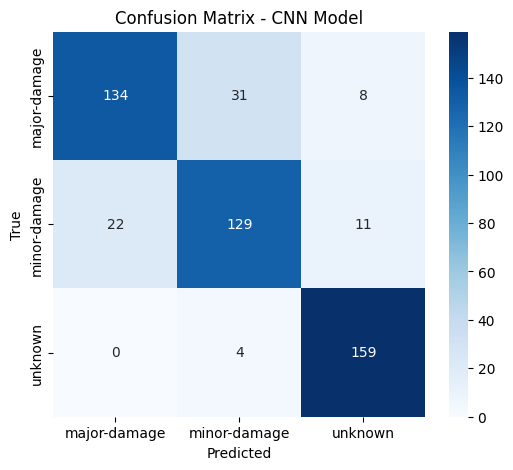

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CNN Model')
plt.show()

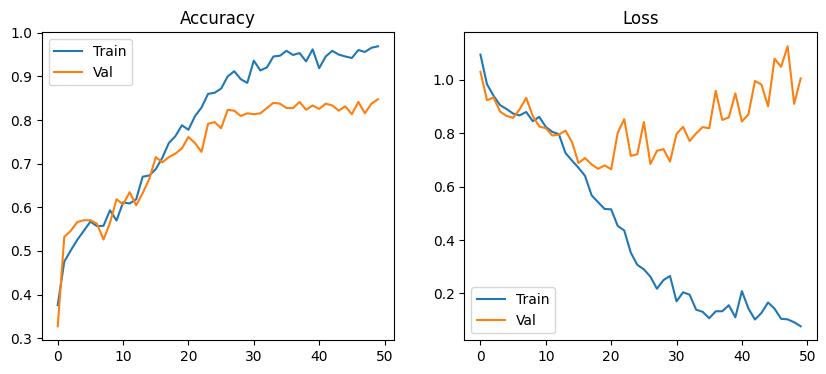

In [13]:
# 📉 Plot training curves
# ===========================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.show()